In [1]:
import importlib

import analiza as ana
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import numpy as np

# Ali so Eurojackpot žrebi res naključni?

### Uvod
V projektni nalogi analiziram dobičke in žrebe Eurojackpota v zadnjih osmih letih (od 1. 1. 2018 do 1. 1. 2026). Podatke sem dobila s te [spletne strani.](https://www.euro-jackpot.net/results-archive-2026)

Eurojackpot je evropska loterija, ki se je začela marca 2012. Srečka v Sloveniji stane 2.50€, cilj pa je zadeti pravilnih 5 od 50 in dodatni 2 od 12 številk. Vsota za jackpot narašča, dokler ne doseže maksimalne vrednosti 120 milijonov evrov, ki je bila izplačana že 8-krat.

### Socialni vidik

In [2]:
povprecno_igralcev = ana.df["sodelujoči"].mean()
print(f"V žrebu se v povprečju proda {povprecno_igralcev:,.0f} srečk iz 19 evropskih držav.".replace(",", "."))

povprecna_nagrada = ana.df["zmagovalci"].mean()
print(f"V žrebu je v poprečju {povprecna_nagrada:,.0f} sodelujočih, ki zadanejo eno od nagrad. Torej okoli {povprecno_igralcev // povprecna_nagrada:,.0f}% povrne svoj vloženi denar ali zadane kaj več.".replace(",", "."))

V žrebu se v povprečju proda 22.138.322 srečk iz 19 evropskih držav.
V žrebu je v poprečju 749.001 sodelujočih. ki zadanejo eno od nagrad. Torej okoli 29% povrne svoj vloženi denar ali zadane kaj več.


Spodnji graf prikazuje število prodanih srečk v mesecu dni. Opazimo, da število prodanih srečk narašča iz leta v leto in da so največji vrhovi v splošnem v času zime.

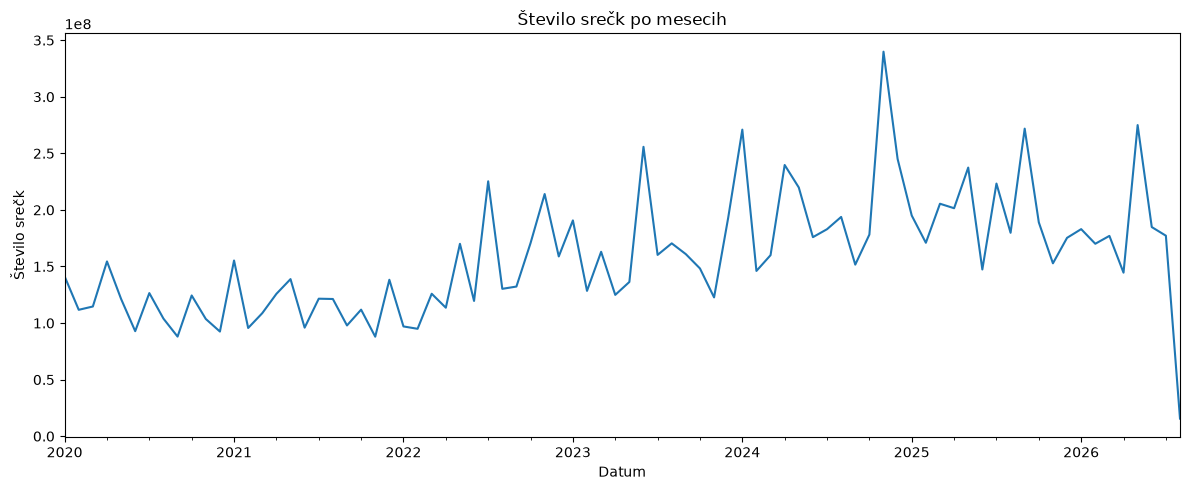

In [3]:
ana.igralci_na_mesec.plot(x="datum", y="stevilo_igralcev", figsize=(12,5))
plt.ylabel("Število srečk")
plt.xlabel("Datum")
plt.title("Število srečk po mesecih")
plt.tight_layout()
plt.show()

Še graf, ki prikazuje število prodanih srečk na mesec.

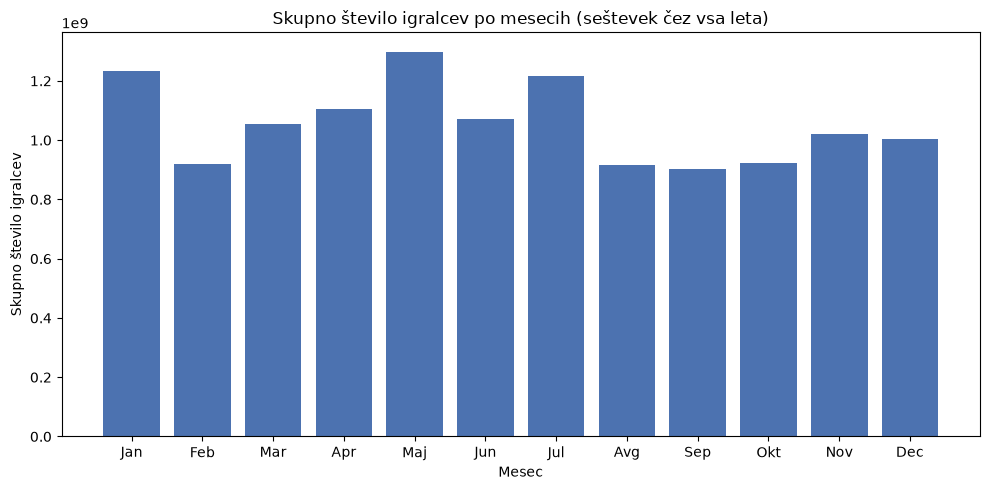

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(ana.imena_mesecev, ana.vsota_po_mesecu.values, color="#4C72B0")
plt.xlabel("Mesec")
plt.ylabel("Skupno število igralcev")
plt.title("Skupno število igralcev po mesecih (seštevek čez vsa leta)")
plt.tight_layout()
plt.show()

Pričakovali bi, da bo po največjem izplačilu (120 milijonov €) število igralcev naraslo, pa iz grafa vidimo, da to sploh ni res. V resnici je večja motivacija za sodelovanje naraščajoča vsota možnega dobitka. Spodnji graf kaže primer zadnjega največjega izplačila.

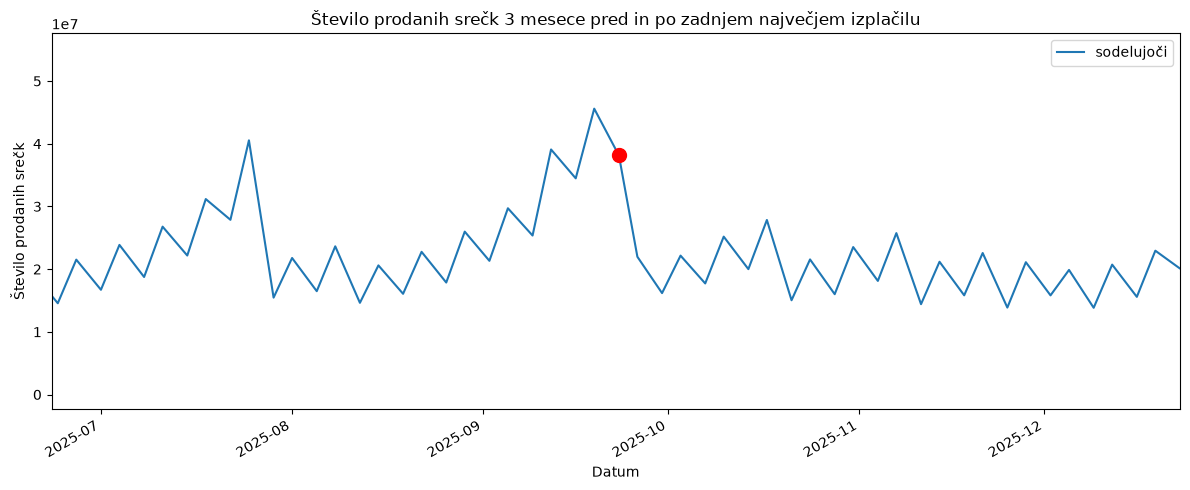

In [5]:
ana.df.plot(x="datum", y="sodelujoči", figsize=(12,5))
plt.ylabel("Število prodanih srečk")
plt.xlabel("Datum")
plt.title("Število prodanih srečk 3 mesece pred in po zadnjem največjem izplačilu")
plt.xlim(pd.Timestamp("2025-06-23"), pd.Timestamp("2025-12-23"))
plt.tight_layout()


tocka_datum = pd.Timestamp("2025-09-23")
tocka_vrednost = ana.df.loc[ana.df["datum"] == tocka_datum, "sodelujoči"].values[0]

plt.scatter(tocka_datum, tocka_vrednost, color="red", s=100, zorder=5)
plt.show()

### Statistični vidik

Spodnja grafa prikazujeta najbolj in najmanj pogosto izžrebane številke in število njihovih pojavitev.

In [6]:
print("5 najpogostejših številk (od 1 do 50):")
ana.top_prvih_pet.index += 1
display(ana.top_prvih_pet)

print("\n5 najmanj pogostih številk:")
ana.najmanj_prvih_pet.index = range(46, 51)
display(ana.najmanj_prvih_pet)

5 najpogostejših številk (od 1 do 50):


,stevilka,pogostost
1,17,73
2,11,73
3,34,72
4,23,69
5,20,68



5 najmanj pogostih številk:


,stevilka,pogostost
46,10,48
47,40,47
48,24,46
49,33,46
50,25,40


Podobno še za zadnji dve številki.

In [7]:
print("5 najpogostejših številk (od 1 do 50):")
ana.top_zadnji_dve.index += 1
display(ana.top_zadnji_dve)

print("\n5 najmanj pogostih številk:")
ana.najmanj_zadnji_dve.index = range(8, 13)
display(ana.najmanj_zadnji_dve)

5 najpogostejših številk (od 1 do 50):


,stevilka,pogostost
1,5,113
2,3,106
3,7,102
4,9,99
5,10,99



5 najmanj pogostih številk:


,stevilka,pogostost
8,8,97
9,4,94
10,2,90
11,12,83
12,11,65


Same številke se žrebajo fizično, v mestu Helsinki na Finskem, s pomočjo oštevilčenih žogic. Spodnja grafa prikazujeta razporeditev pogostosti izžrebanih številk, ki kaže na čisto naključnost.

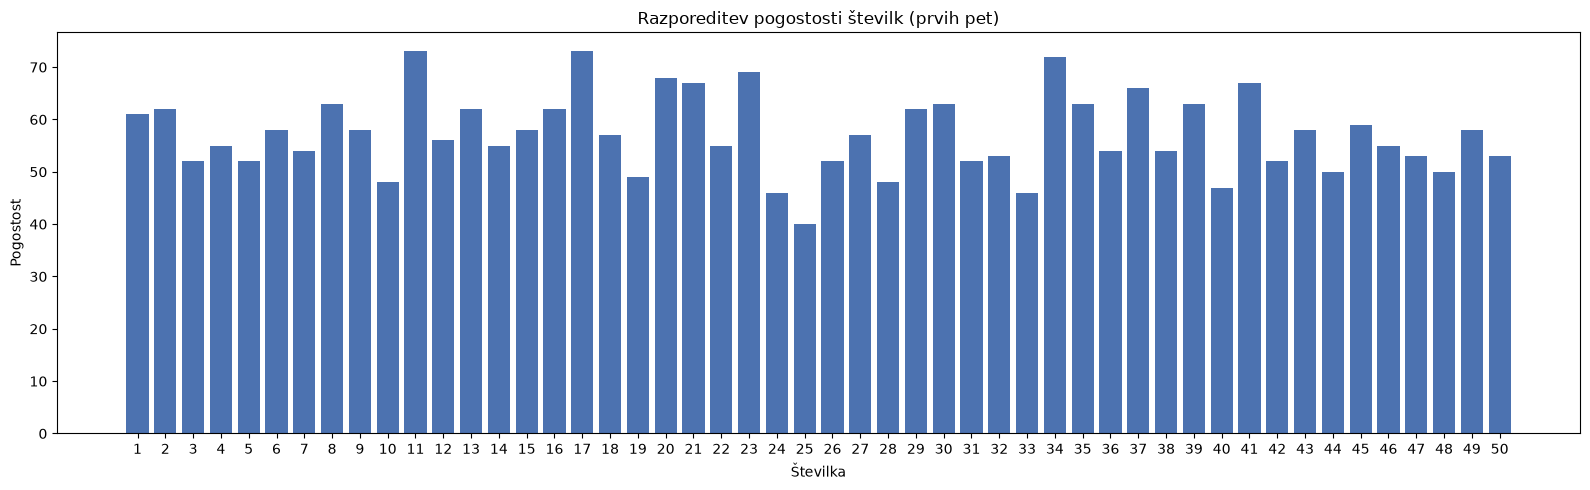

In [8]:
plt.figure(figsize=(16, 5))
prvih_pet_sorted = dict(sorted(ana.prvih_pet_counter.items()))

plt.bar(prvih_pet_sorted.keys(), prvih_pet_sorted.values(), color="#4C72B0")
plt.xlabel("Številka")
plt.ylabel("Pogostost")
plt.title("Razporeditev pogostosti številk (prvih pet)")
plt.xticks(range(1, 51))
plt.tight_layout()
plt.show()

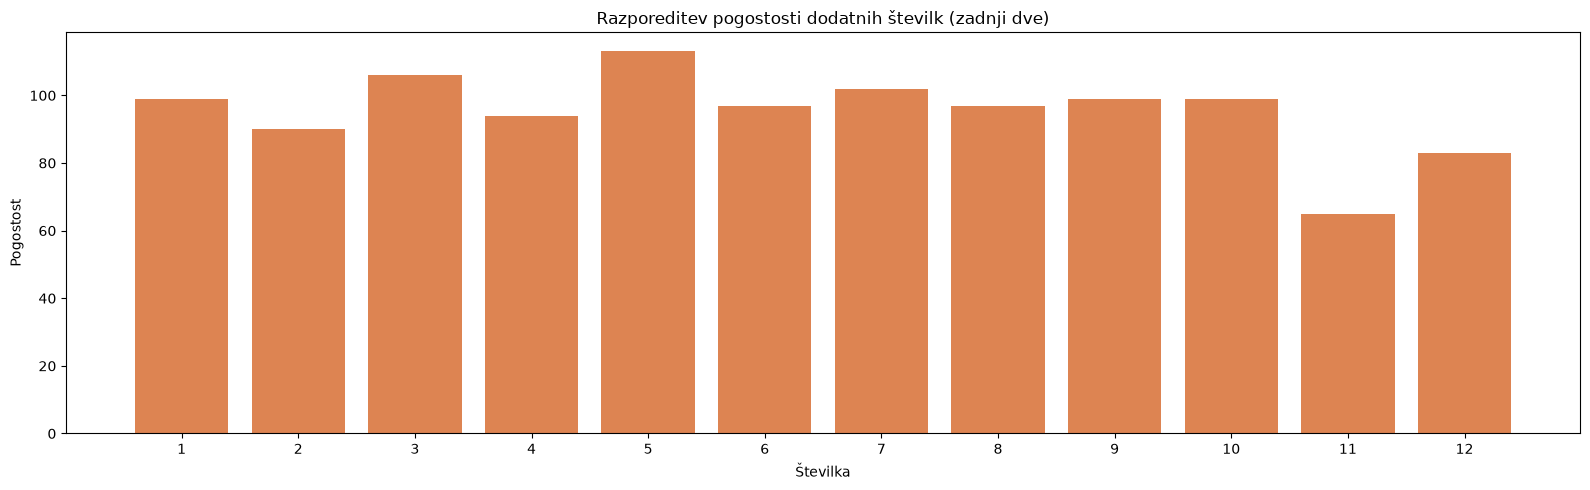

In [9]:
plt.figure(figsize=(16, 5))
zadnji_dve_sorted = dict(sorted(ana.zadnji_dve_counter.items()))

plt.bar(zadnji_dve_sorted.keys(), zadnji_dve_sorted.values(), color="#DD8452")
plt.xlabel("Številka")
plt.ylabel("Pogostost")
plt.title("Razporeditev pogostosti dodatnih številk (zadnji dve)")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

Spodnji graf prikazuje porazdelitev vsote petih izžrebanih številk pri posameznem žrebu. Opazimo, da porazdelitev po obliki spominja na Gaussovo (normalno) porazdelitev.

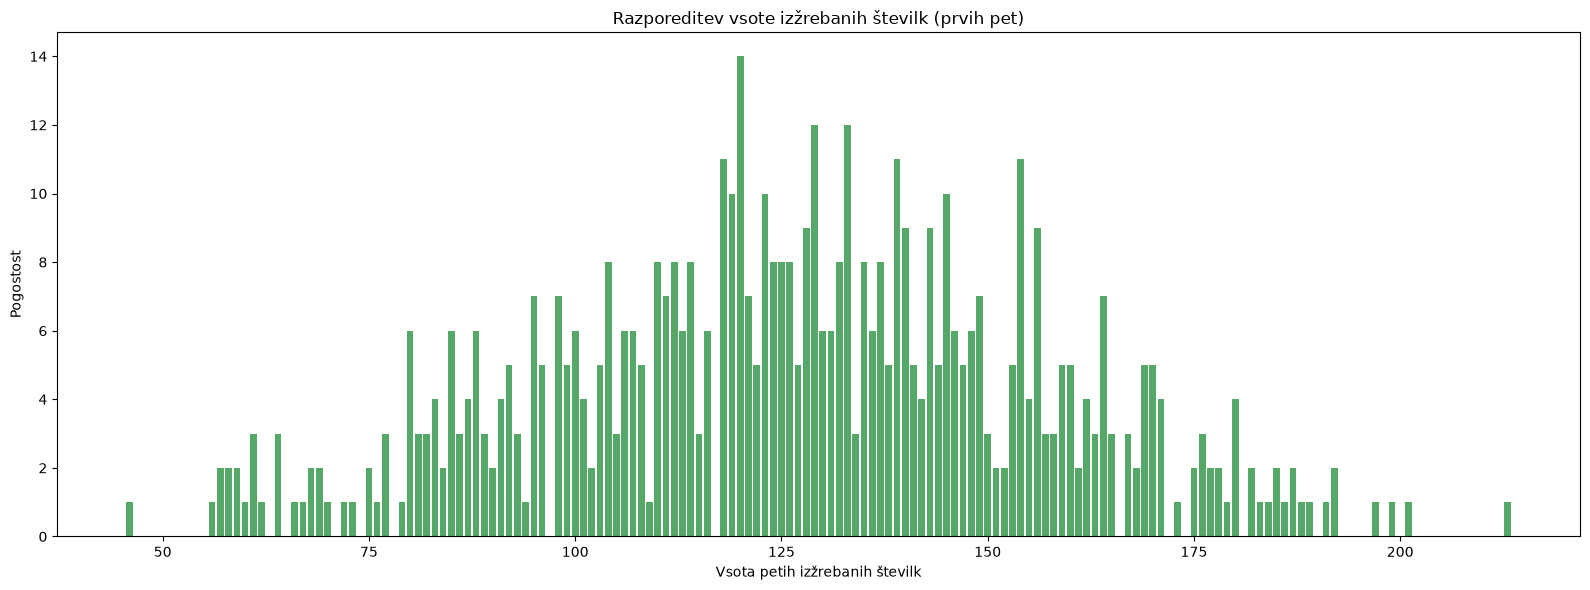

In [10]:
vsota_sorted = dict(sorted(ana.vsota_counter.items()))

plt.figure(figsize=(16, 6))
plt.bar(vsota_sorted.keys(), vsota_sorted.values(), color="#55A868", width=0.8)
plt.xlabel("Vsota petih izžrebanih številk")
plt.ylabel("Pogostost")
plt.title("Razporeditev vsote izžrebanih številk (prvih pet)")
plt.tight_layout()
plt.show()

Spodnji graf prikazuje še najpogostejše pare prvih petih številk.

In [11]:
ana.top10_pari.index = ana.top10_pari.index + 1
display(ana.top10_pari)

,par,pogostost
1,"(27, 41)",12
2,"(15, 35)",12
3,"(17, 30)",12
4,"(34, 49)",11
5,"(17, 39)",11
6,"(40, 41)",11
7,"(21, 29)",11
8,"(21, 34)",11
9,"(23, 38)",11
10,"(11, 23)",11


Na podlagi tabele bi napačno sklepali, da so nekateri pari bolj pogosti kot drugi. Vendar to bolj jasno prikaže spodnji graf, ki v tabeli kaže njihovo razporeditev.

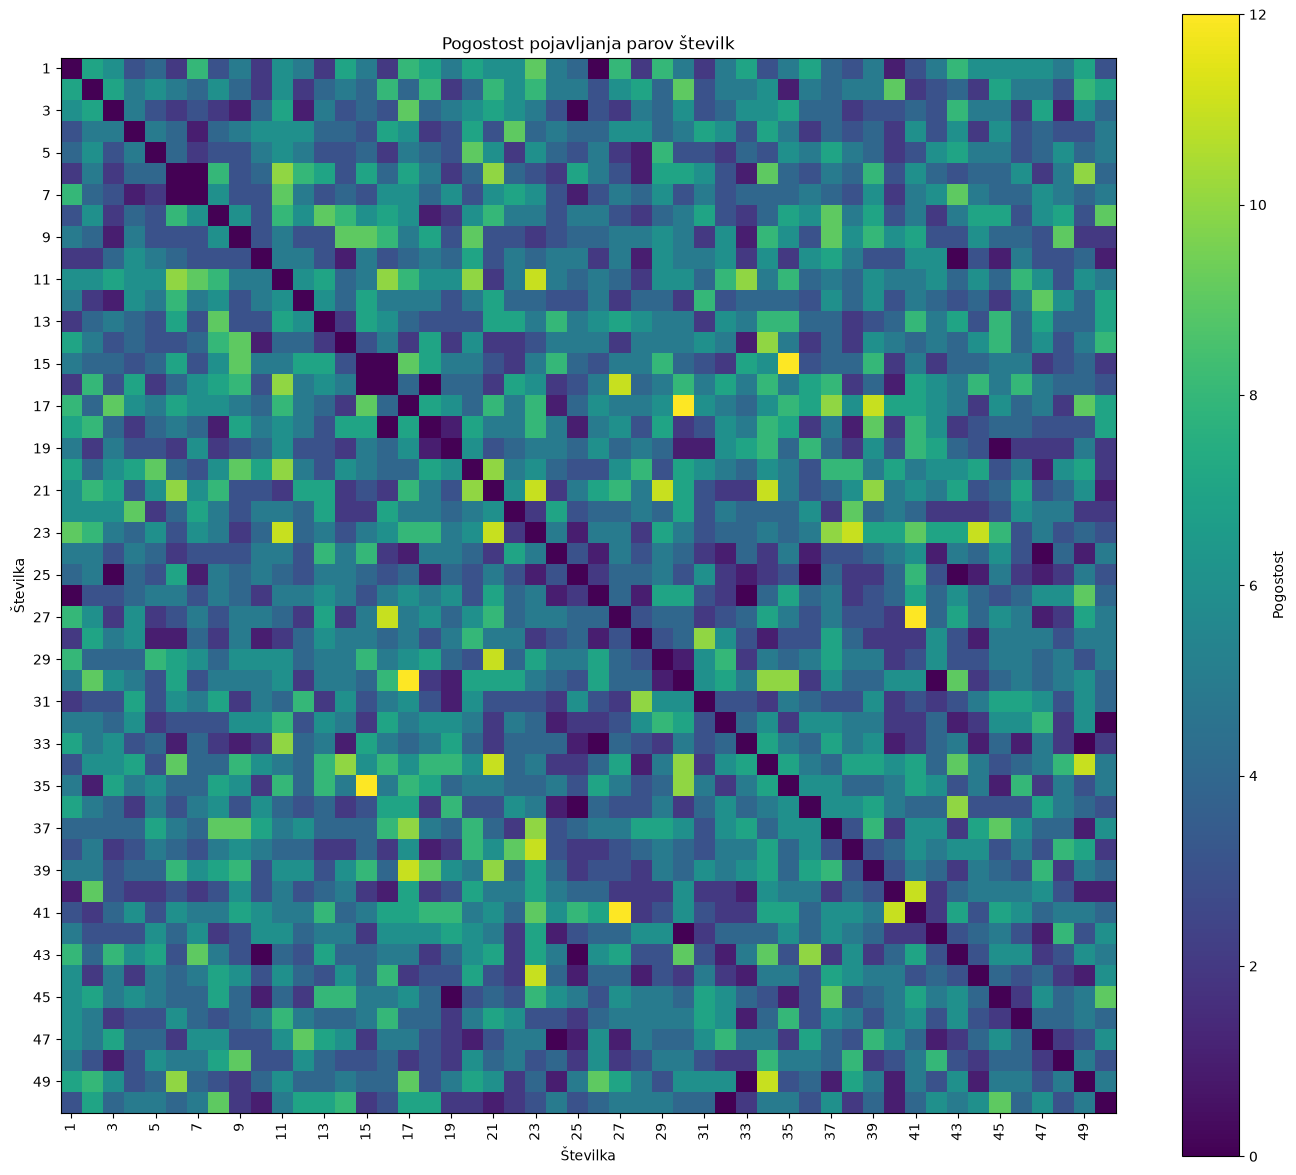

In [12]:
fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(ana.matrika_parov, cmap="viridis")

ax.set_xticks(range(0, 50, 2))
ax.set_xticklabels(range(1, 51, 2), rotation=90)
ax.set_yticks(range(0, 50, 2))
ax.set_yticklabels(range(1, 51, 2))

ax.set_xlabel("Številka")
ax.set_ylabel("Številka")
ax.set_title("Pogostost pojavljanja parov številk")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Pogostost")

plt.tight_layout()
plt.show()

Graf prikazuje razporeditev sodih in lihih številk v žrebih.

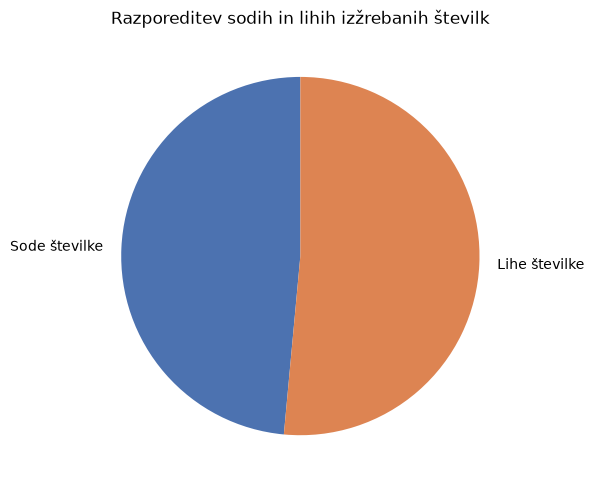

In [13]:
sodih = sum(pogostost for stevilka, pogostost in ana.prvih_pet_counter.items() if stevilka % 2 == 0)
lihih = sum(pogostost for stevilka, pogostost in ana.prvih_pet_counter.items() if stevilka % 2 != 0)

plt.figure(figsize=(6, 6))
plt.pie(
    [sodih, lihih],
    labels=["Sode številke", "Lihe številke"],
    colors=["#4C72B0", "#DD8452"],
    startangle=90
)
plt.title("Razporeditev sodih in lihih izžrebanih številk")
plt.tight_layout()
plt.show()

## Zaključek

Analiza šestih let žrebov Eurojackpota ni pokazala nobenega statistično pomembnega odstopanja od naključnosti – razporeditev številk, parov in vsot izžrebanih kombinacij je skladna s tem, kar bi pričakovali pri poštenem žrebanju. 
Za eksperiment sem vplačala srečko z najbolj statistično verjetno kombinacijo številk, torej: 17, 11, 34, 23, 20 in 5, 3. Zadela nisem ničesar, kar le potrjuje, da preteklost žrebov ne vpliva na prihodnost in da Eurojackpot ostaja igra čiste sreče.